In [ ]:
import scanpy as sc

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [2]:
adata = sc.read_h5ad("SmoNull_Brain_system.h5ad")

In [4]:
adata


AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)', 'dispersions', 'dispersions_norm', 'highly_variable_scran', 'highly_variable_nbatches_scran', 'highly_variable_intersection_scran'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'X

# Generating Leiden Clusterings 

In [ ]:
resolutions = [.25,.5,1,2,5]

In [8]:
# Testing to make sure the key_added function work as expected
for res in resolutions:
    print("leiden_"+str(res).replace(".", "_")+"_log1p")

leiden_0_25_log1p
leiden_0_5_log1p
leiden_1_log1p
leiden_2_log1p
leiden_3_log1p
leiden_5_log1p


In [9]:
# perform leiden clustering for all 3 neighbor
for resolution in resolutions:
    sc.tl.leiden(adata, resolution = resolution, neighbors_key="neighbors_log1p", key_added="leiden_"+str(resolution).replace(".", "_")+"_log1p")
    sc.tl.leiden(adata, resolution = resolution, neighbors_key="neighbors_scran", key_added="leiden_"+str(resolution).replace(".", "_")+"_scran")
    sc.tl.leiden(adata, resolution = resolution, neighbors_key="neighbors_pearson", key_added="leiden_"+str(resolution).replace(".", "_")+"_pearson")


/scratch/local/jobs/46958815/ipykernel_10193/2143155127.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = resolution, neighbors_key="neighbors_log1p", key_added="leiden_"+str(resolution).replace(".", "_")+"_log1p")


In [11]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_va

In [12]:
adata.write_h5ad("/project/imoskowitz/yubin/1-sc_practice/Data/SmoNull_Brain_system.h5ad")

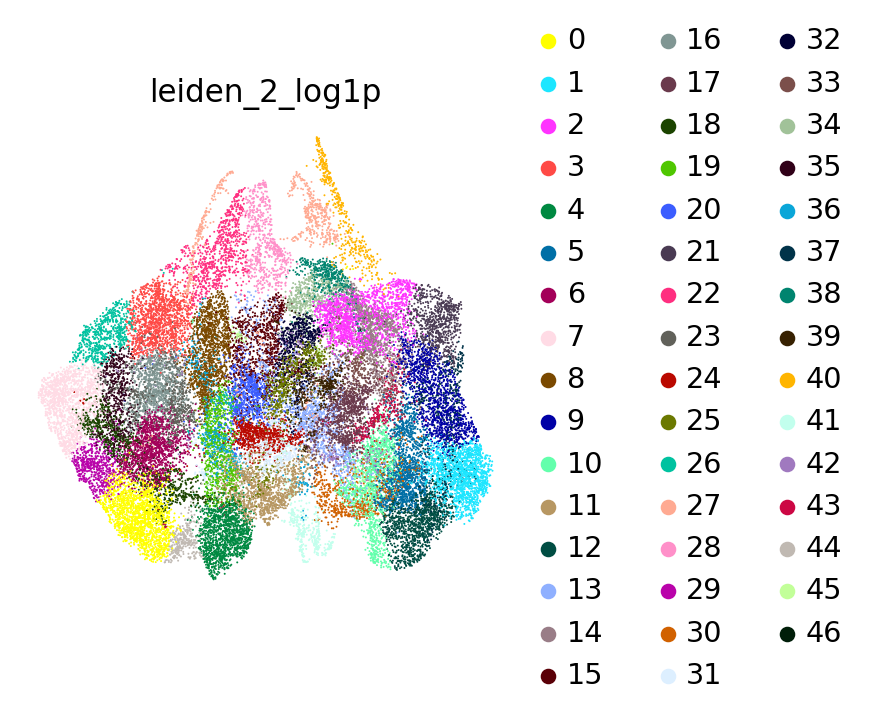

In [17]:
sc.pl.embedding(adata, basis="X_umap_log1p", color="leiden_2_log1p")